## Exercise 1: Bayesian optimization
1. Define an objective function which returns the analytic expression of a 1d polynomial with coefficients f(x) = 0.05 (x^6 - 2 x^5 - 28 x^4 + 28 x^3 + 12 x^2 -26 x + 100).

2. Plot the previous function using a linear grid of points in x between [-5, 6].

3. Define an uniform search domain space using hyperopt. With hyperopt.pyll.stochastic.sample build an histogram with samples from that space.

4. Perform the objective function minimization using the Tree-structured Parzen Estimator model, 2000 evaluations and store the trials using hyperopt.Trials. Print to screen the best value of x. Show scatter plot with the x-value vs iteration together with the final best value of x. Show the histogram of x-values extracted during the scan.

5. Repeat the previous point now using a random search algorithm.

In [1]:
import hyperopt
from hyperopt import hp, tpe, Trials, fmin, rand
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    p = np.poly1d([1,-2,-28,28,12,-26,100])
    return p(x)*0.05

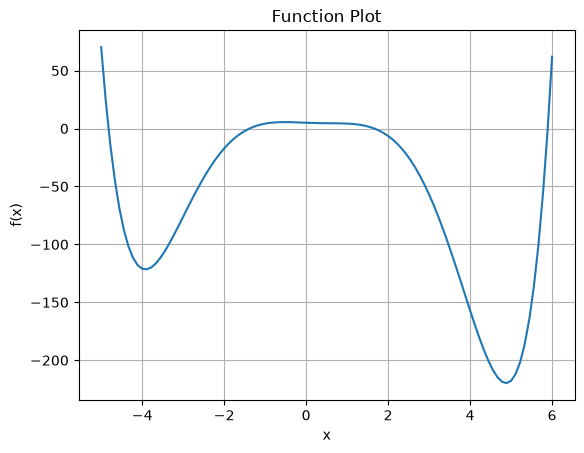

In [8]:
# . Plot the previous function using a linear grid of points in x between [-5, 6].
x_values = np.linspace(-5, 6, 100)
y_values = f(x_values)

plt.plot(x_values, y_values)
plt.title("Function Plot")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()  
plt.show()


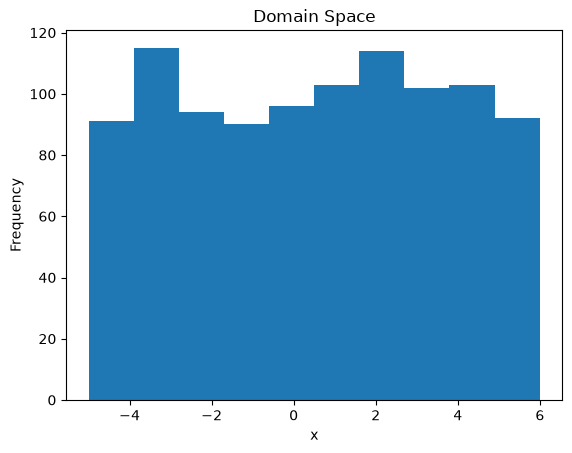

100%|██████████| 2000/2000 [00:05<00:00, 336.51trial/s, best loss: -219.80119214251064]
{'x': np.float64(4.877829657237992)}


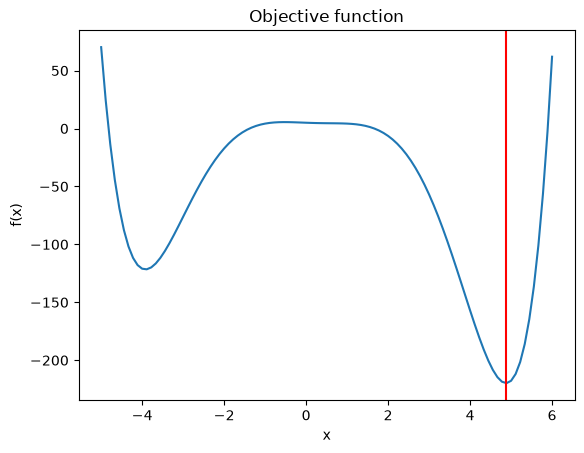

In [4]:
space = hp.uniform('x', -5, 6)
plt.hist([hyperopt.pyll.stochastic.sample(space) for _ in range(1000)])
plt.title("Domain Space")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

# Run 2000 evals with the tpe algorithm
tpe_trials = Trials()
tpe_best = fmin(fn=f, space=space,
                algo=tpe.suggest, trials=tpe_trials,
                max_evals=2000)
print(tpe_best)

# Point 2-3
x = np.linspace(-5, 6, 100)
plt.plot(x, f(x))
plt.axvline(tpe_best['x'], color='red')
plt.title("Objective function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

100%|██████████| 2000/2000 [00:02<00:00, 940.91trial/s, best loss: -219.79834628105277] 
{'x': np.float64(4.873434412306382)}


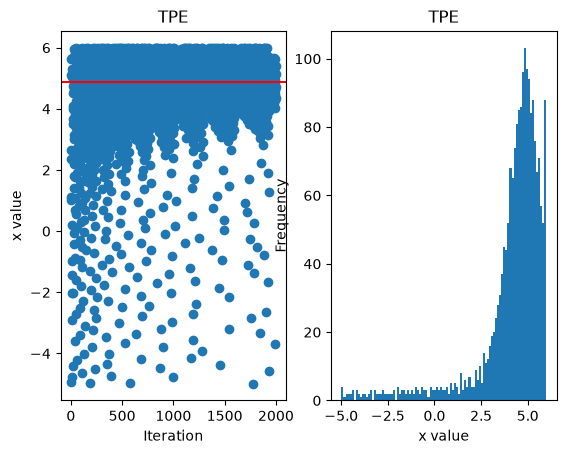

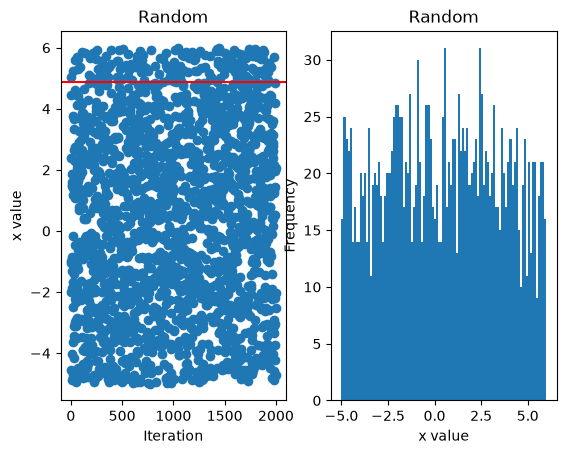

In [9]:
# Point 4
_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(tpe_trials.idxs_vals[0]['x'], tpe_trials.idxs_vals[1]['x'])
ax1.axhline(tpe_best['x'], color='red')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("x value")
ax1.set_title("TPE")
ax2.hist(tpe_trials.idxs_vals[1]['x'], bins=100)
ax2.set_xlabel("x value")
ax2.set_ylabel("Frequency")
ax2.set_title("TPE")

# Point 5
rdn_trials = Trials()
rdn_best = fmin(fn=f, space=space,
                algo=rand.suggest, trials=rdn_trials,
                max_evals=2000)
print(rdn_best)

_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(rdn_trials.idxs_vals[0]['x'], rdn_trials.idxs_vals[1]['x'])
ax1.axhline(rdn_best['x'], color='red')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("x value")
ax1.set_title("Random")
ax2.hist(rdn_trials.idxs_vals[1]['x'], bins=100)
ax2.set_xlabel("x value")
ax2.set_ylabel("Frequency")
ax2.set_title("Random")
plt.show()


## Exercise 2: Hyperparameter scan for classifier
Write a DL regression model using Keras with the following steps:

Data loading

Load the mnist dataset from tensorflow.keras.datasets.mnist. Study the dataset size (shape) and normalize the pixels.

DNN model

Design a NN architecture for the classification of all digits.

Hyperparameter scan

Define a function which parametrizes the learning rate and the number of units of the DNN model using a python dict.

Use the Tree-structured Parzen Estimator with the hyperopt library.

Plot the accuracy vs learning rate and number of layers for each trial.

In [1]:
# Import delle librerie: TensorFlow/Keras per costruire e allenare la rete neurale,
# hyperopt per la ricerca bayesiana degli iperparametri (TPE)
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from functools import partial
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

I0000 00:00:1787916128.709525   71848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787916128.827390   71848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Teoria: Data loading

Il dataset **MNIST** contiene 70000 immagini in scala di grigi (28x28 pixel) di cifre scritte a mano (0-9), gia' divise in training set (60000 immagini) e test set (10000 immagini). Ogni pixel ha un valore intero tra 0 e 255.

Prima di darle in pasto alla rete conviene **normalizzare** i pixel portandoli nell'intervallo [0, 1] (dividendo per 255): input piu' piccoli e omogenei rendono l'addestramento piu' stabile e veloce, perche' i gradienti calcolati durante il training restano su scale ragionevoli.

train: (60000, 28, 28)
test: (10000, 28, 28)


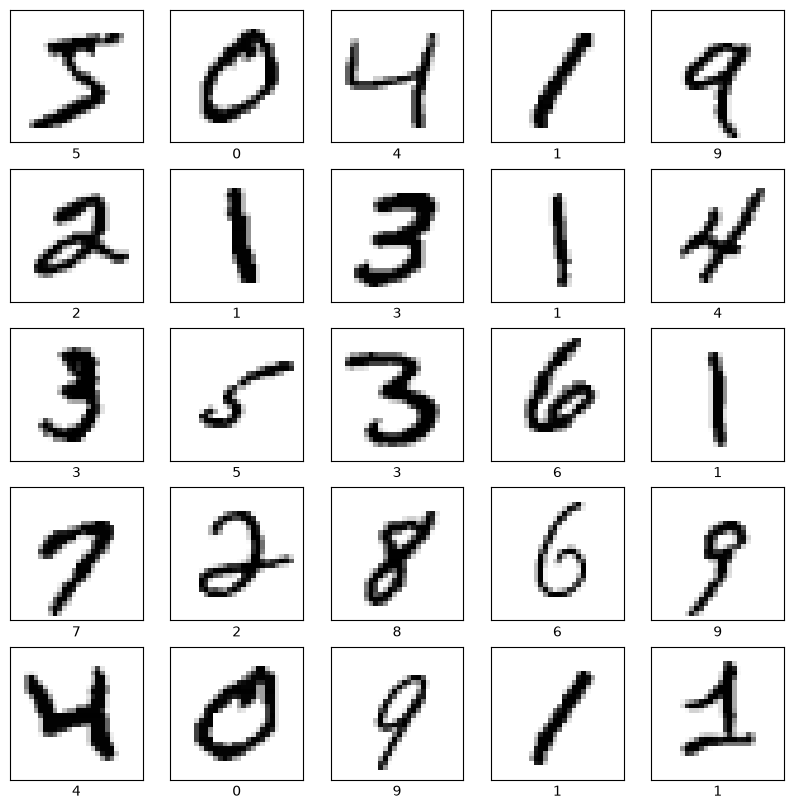

In [2]:
# Punto 1: Data loading
# Carichiamo il dataset MNIST, gia' diviso in training set e test set
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalizziamo i pixel: da [0, 255] a [0, 1]
train_images = train_images / 255
test_images = test_images / 255

# Controlliamo la dimensione (shape) dei due set
print('train:', train_images.shape)
print('test:', test_images.shape)

# Funzione di supporto per visualizzare alcune immagini di esempio con la relativa etichetta
def plot_sample(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(labels[i])
    plt.show()

plot_sample(train_images, train_labels)

### Teoria: DNN model

L'architettura scelta e' una rete **fully-connected** (MLP) molto semplice:

- **Flatten**: trasforma ogni immagine 28x28 in un vettore di 784 valori, perche' i layer `Dense` si aspettano un input 1D.
- **Dense(hidden, relu)**: layer nascosto con attivazione **ReLU**, che introduce non-linearita' e permette alla rete di imparare pattern complessi.
- **Dense(10, softmax)**: layer di output con 10 neuroni (uno per cifra) e attivazione **softmax**, che trasforma gli output in una distribuzione di probabilita' sulle 10 classi.

Come loss usiamo `sparse_categorical_crossentropy` (adatta quando le etichette sono interi e non one-hot) e come metrica l'`accuracy`.

Definiamo due funzioni riutilizzabili — `train` (costruisce, allena e restituisce il modello) e `test` (calcola loss/accuracy sul test set) — che verranno riusate anche nello scan degli iperparametri. Prima pero' costruiamo e alleniamo "a mano" un primo modello di riferimento, per verificare che l'architettura funzioni.

In [3]:
# Punto 2: DNN model
# Funzione che costruisce e allena il modello, parametrizzata su numero di unita' e learning rate.
# validation_split > 0 tiene da parte una frazione del training set per la validazione:
# serve nello scan degli iperparametri, per non selezionare i parametri sul test set.
def train(features, labels, parameters, epochs=5, validation_split=0.0, verbose=1):
    model = Sequential()
    model.add(Input(shape=(28,28)))                                           # input esplicito (input_shape dentro Flatten e' deprecato in Keras 3)
    model.add(Flatten())                                                      # 28x28 -> vettore di 784 valori
    model.add(Dense(units=int(parameters['layer_size']), activation='relu'))  # hidden layer, dimensione parametrizzabile
    model.add(Dense(10, activation='softmax'))                                # output: probabilita' sulle 10 cifre

    adam = Adam(learning_rate=parameters['learning_rate'])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=adam, metrics=['accuracy'])
    history = model.fit(features, labels, epochs=epochs,
                        validation_split=validation_split, verbose=verbose)
    return model, history

# Funzione che valuta il modello sul test set
def test(model, features, labels):
    acc = model.evaluate(features, labels)
    return acc

# Modello di riferimento costruito "a mano" (2 unita' nel hidden layer) per verificare che l'architettura funzioni
model = Sequential() # questo comando crea un modello vuoto, a cui aggiungeremo i layer successivamente. Sequential significa che i layer sono "in serie", uno dopo l'altro, senza ramificazioni.
model.add(Input(shape=(28,28))) # dichiarazione esplicita della forma dell'input
model.add(Flatten()) # Flatten serve a trasformare l'immagine 28x28 in un vettore di 784 valori, che e' il formato richiesto dal layer denso successivo.
model.add(Dense(2, activation='relu')) # questo layer ha 2 unita' (neuroni) e funzione di attivazione ReLU
model.add(Dense(10, activation='softmax')) # questo layer ha 10 unita' (una per ogni cifra) e funzione di attivazione softmax
model.summary() # serve a stampare la struttura del modello, utile per il debug e per capire quanti parametri ci sono
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # prepara il modello per l'allenamento, specificando l'ottimizzatore, la loss e le metriche da monitorare
model.fit(train_images, train_labels, epochs=5) # questa funzione allena il modello sui dati di training per 5 epoche (passaggi su tutto il dataset)
test_acc = test(model, test_images, test_labels) # questa funzione valuta il modello sui dati di test e restituisce [loss, accuracy]
print(f'Test loss {test_acc[0]:.4f} - Test accuracy {test_acc[1]:.4f}')

# Verifichiamo anche la funzione train() con una configurazione di parametri fissata
test_setup = {
    'layer_size': 2,
    'learning_rate': 0.001
} # configurazione di test per la funzione train(), 2 neuroni nel hidden layer e learning rate 1.0
model, _ = train(train_images, train_labels, test_setup) # allena il modello con la configurazione di test (train() ora restituisce anche la history)
print('Accuracy on test set is:', test(model, test_images, test_labels)[1])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,600 (6.25 KB)

 Trainable params: 1,600 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4471 - loss: 1.5335
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6021 - loss: 1.1602
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6407 - loss: 1.0752
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6587 - loss: 1.0339
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6696 - loss: 1.0090
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6721 - loss: 1.0223
Test loss 1.0223 - Test accuracy 0.6721
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3027 - loss: 1.8298
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5110 - loss: 1.3170
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5426 - loss: 1.2360
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5661 - loss: 1.1963
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5768 - loss: 1.1734
313/313 ━━━━━━━

### Teoria: hyperparameter scan con TPE

Vogliamo trovare la combinazione di `learning_rate` e numero di unita' del hidden layer (`layer_size`) che massimizza l'accuracy, usando **hyperopt** con l'algoritmo **Tree-structured Parzen Estimator (TPE)** (lo stesso usato nell'Esercizio 1).

- **Funzione obiettivo** (`hyper_func`): allena un modello con i parametri proposti da hyperopt e restituisce un dizionario con `loss` e `status`. Siccome `fmin` **minimizza** la loss, mentre a noi interessa **massimizzare** l'accuracy, restituiamo `-accuracy` come loss.
- **Su quali dati misuriamo l'accuracy?** Su un **validation set** ricavato dal training set (`validation_split=0.2`), *non* sul test set. Se scegliessimo gli iperparametri guardando il test set, quest'ultimo entrerebbe a far parte della procedura di ottimizzazione e l'accuracy finale non sarebbe piu' una stima non distorta della capacita' di generalizzazione: il test set va toccato **una volta sola**, alla fine, con la configurazione vincente.
- **Spazio di ricerca** (`search_space`):
  - `layer_size`: scelto tra valori discreti con `hp.choice` (10, 30, 50, 70, 90).
  - `learning_rate`: campionato con `hp.loguniform`, adatto quando il parametro varia su piu' ordini di grandezza (qui tra e^-10 ed e^0).
- **Numero di valutazioni**: TPE costruisce il proprio modello probabilistico solo dopo una fase iniziale di campionamento casuale, controllata da `n_startup_jobs` (default **20**). Con poche valutazioni si otterrebbe quindi una semplice random search con un nome piu' elegante. Qui usiamo `max_evals=30` e abbassiamo `n_startup_jobs` a 10, cosi' che 20 prove su 30 siano effettivamente guidate dal modello TPE. Per contenere i tempi riduciamo le epoche di training a 3 durante lo scan.
- **Trials**: oggetto che tiene traccia di tutte le prove effettuate durante la ricerca, cosi' da poterle analizzare e plottare in seguito.

In [4]:
# Punto 3: Hyperparameter scan
def hyper_func(params):
    # Allena il modello con i parametri proposti da hyperopt e restituisce -accuracy
    # (fmin minimizza, noi vogliamo massimizzare l'accuracy).
    # L'accuracy e' misurata sul validation set ricavato dal training set: il test set
    # non deve entrare nella selezione degli iperparametri.
    _, history = train(train_images, train_labels, params,
                       epochs=3, validation_split=0.2, verbose=0)
    val_acc = history.history['val_accuracy'][-1]  # accuracy di validazione all'ultima epoca
    return {'loss': -val_acc, 'status': STATUS_OK}

search_space = {
    'layer_size': hp.choice('layer_size', np.arange(10, 100, 20)),
    'learning_rate': hp.loguniform('learning_rate', -10, 0)
} # definizione dello spazio di ricerca degli iperparametri: layer_size puo' assumere valori tra 10 e 90 (in passi di 20), learning_rate e' distribuito log-uniformemente tra exp(-10) e exp(0)

trials = Trials() # questa classe serve a tenere traccia dei risultati delle valutazioni dei modelli durante la ricerca degli iperparametri

# n_startup_jobs=10: dopo le prime 10 prove casuali, TPE inizia davvero a proporre
# configurazioni informate dalle prove precedenti (con il default di 20 e poche
# valutazioni la ricerca resterebbe puramente casuale).
best = fmin(hyper_func, search_space,
            algo=partial(tpe.suggest, n_startup_jobs=10),
            max_evals=30, trials=trials)

best_params = space_eval(search_space, best)  # space_eval converte gli indici di hp.choice nei valori veri
print('Migliore configurazione trovata:', best_params)

100%|██████████| 30/30 [04:47<00:00,  9.58s/trial, best loss: -0.9664999842643738]
Migliore configurazione trovata: {'layer_size': np.int64(70), 'learning_rate': 0.0012694236635738198}


In [5]:
# Valutazione finale: riallenamento con la configurazione migliore su tutto il training set
# e UNICA valutazione sul test set (che finora non e' mai stato usato per scegliere nulla).
best_model, _ = train(train_images, train_labels, best_params, epochs=5)
final_loss, final_acc = test(best_model, test_images, test_labels)
print(f"Configurazione: {best_params}")
print(f"Accuracy sul test set (stima non distorta): {final_acc * 100:.2f}%")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9160 - loss: 0.2889
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9597 - loss: 0.1361
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9712 - loss: 0.0959
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9766 - loss: 0.0759
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9805 - loss: 0.0619
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.0992
Configurazione: {'layer_size': np.int64(70), 'learning_rate': 0.0012694236635738198}
Accuracy sul test set (stima non distorta): 96.90%


### Nota: le sezioni seguenti usano reti "giocattolo"

Da qui in avanti l'analisi non riguarda piu' `best_model`, ma due reti volutamente
**molto piccole** (`model_toy`, con 5 neuroni nascosti, e `model_deep`, con 8+5 neuroni):
con poche unita' si possono disegnare tutti i neuroni e tutti i pesi uno per uno, cosa
impossibile con le decine di unita' della configurazione ottimale. L'obiettivo qui non
e' massimizzare l'accuracy, ma **guardare dentro** la rete.

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7446 - loss: 0.8338
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8598 - loss: 0.5003
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8717 - loss: 0.4543
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8773 - loss: 0.4323
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8814 - loss: 0.4197
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8837 - loss: 0.4106
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8856 - loss: 0.4028
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8864 - loss: 0.3963
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8884 - loss: 0.3912
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8899 - loss: 0.3864


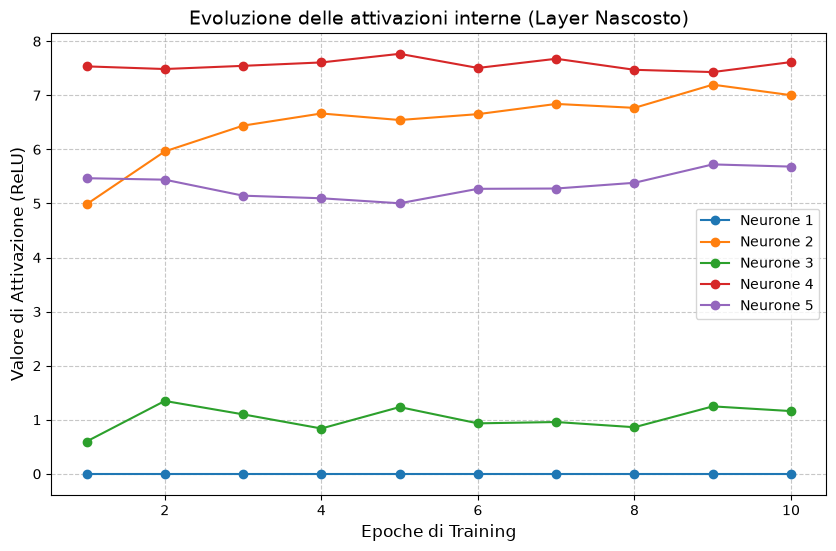

In [6]:
# Selezioniamo un'immagine dal test set
sample_image = test_images[0:1] 

class StoreActivations(Callback):
    def __init__(self, sample_image, extractor_model):
        super().__init__()
        self.sample_image = sample_image
        self.activations_history = [] 
        self.extractor = extractor_model

    def on_epoch_end(self, epoch, logs=None):
        # L'estrattore ora funzionerà senza problemi
        activations = self.extractor.predict(self.sample_image, verbose=0)
        self.activations_history.append(activations[0])

# --- FUNCTIONAL API ---
# Invece di una lista, passiamo esplicitamente i dati da un layer all'altro
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
# Salviamo l'output del layer nascosto in una variabile
hidden_out = Dense(5, activation='relu', name='hidden_layer')(x)
outputs = Dense(10, activation='softmax')(hidden_out)

# 1. Modello principale per l'addestramento (da inputs a outputs)
model_toy = Model(inputs=inputs, outputs=outputs)
model_toy.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# 2. Estrattore (da inputs a hidden_out). Molto più pulito!
extractor = Model(inputs=inputs, outputs=hidden_out)

# 3. Inizializziamo e alleniamo
activation_tracker = StoreActivations(sample_image, extractor)
model_toy.fit(train_images, train_labels, epochs=10, callbacks=[activation_tracker])

# --- CREAZIONE DEL GRAFICO ---
history_matrix = np.array(activation_tracker.activations_history)
epoche_x = range(1, len(history_matrix) + 1)

plt.figure(figsize=(10, 6))
for i in range(history_matrix.shape[1]):
    plt.plot(epoche_x, history_matrix[:, i], label=f'Neurone {i+1}', marker='o')

plt.title("Evoluzione delle attivazioni interne (Layer Nascosto)", fontsize=14)
plt.xlabel("Epoche di Training", fontsize=12)
plt.ylabel("Valore di Attivazione (ReLU)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### attivazione neuroni

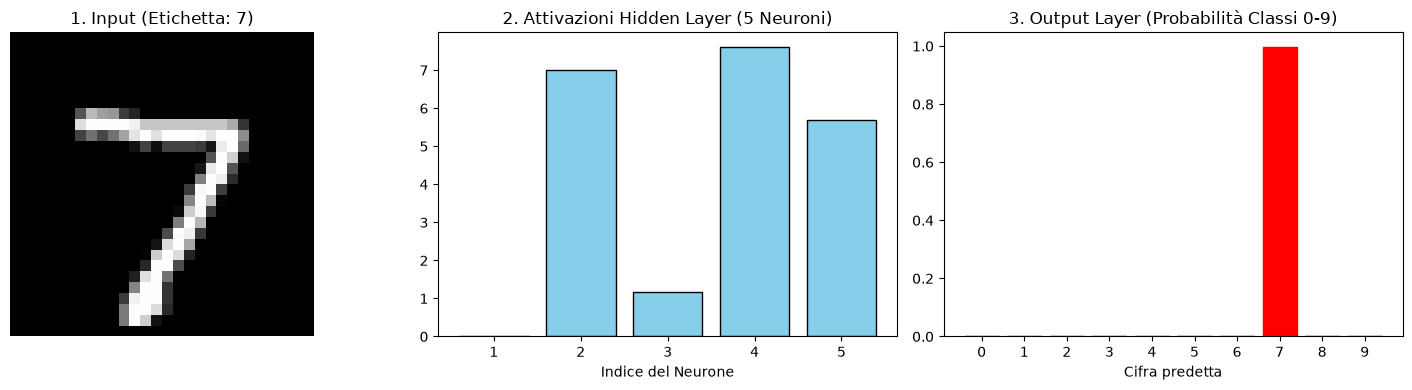

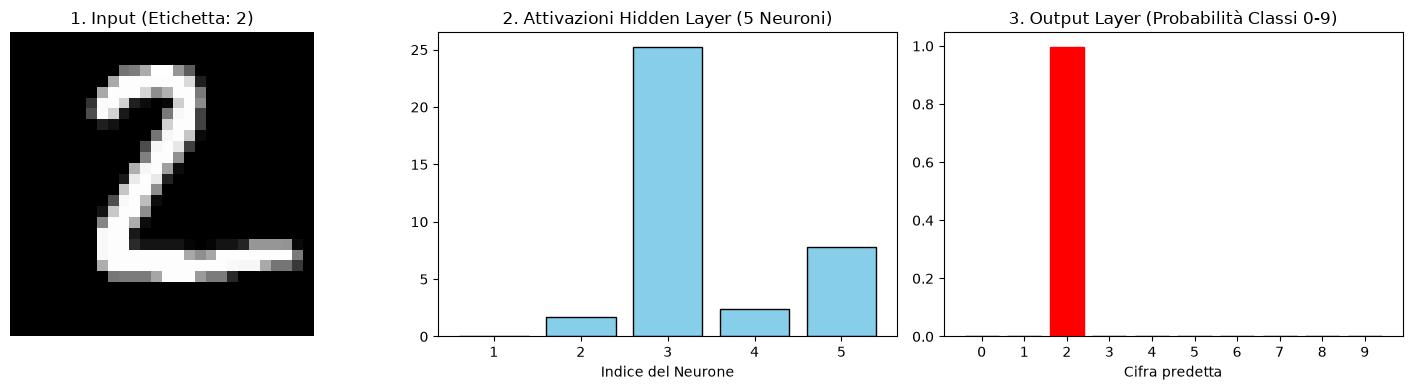

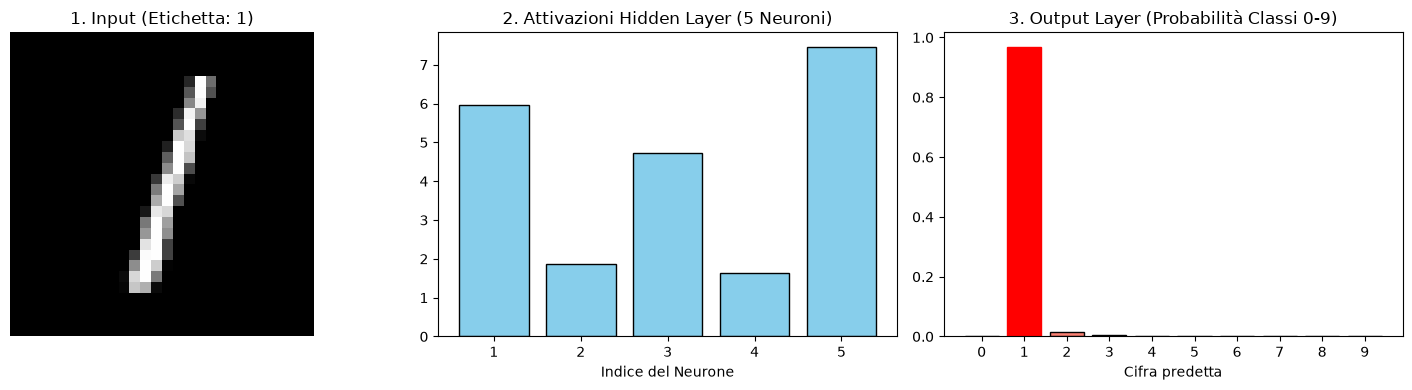

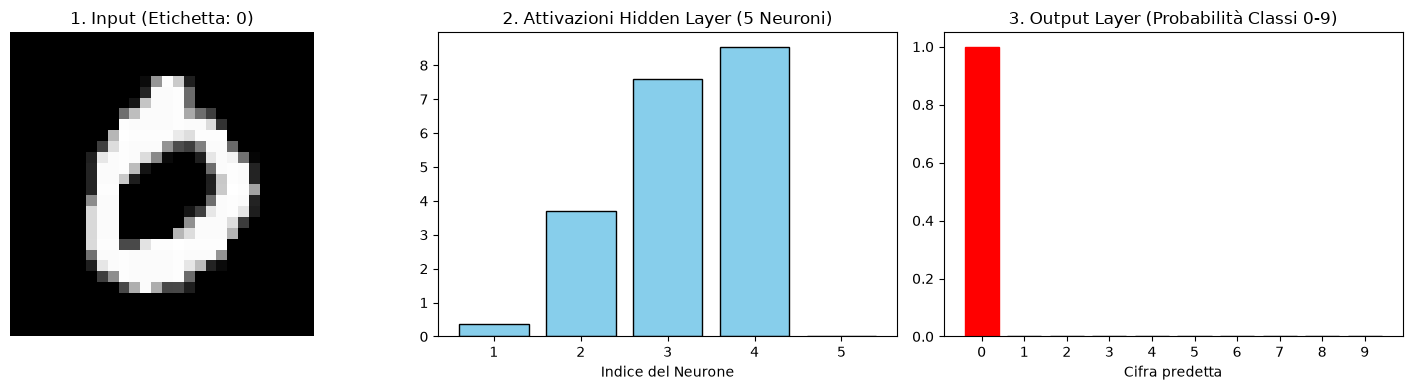

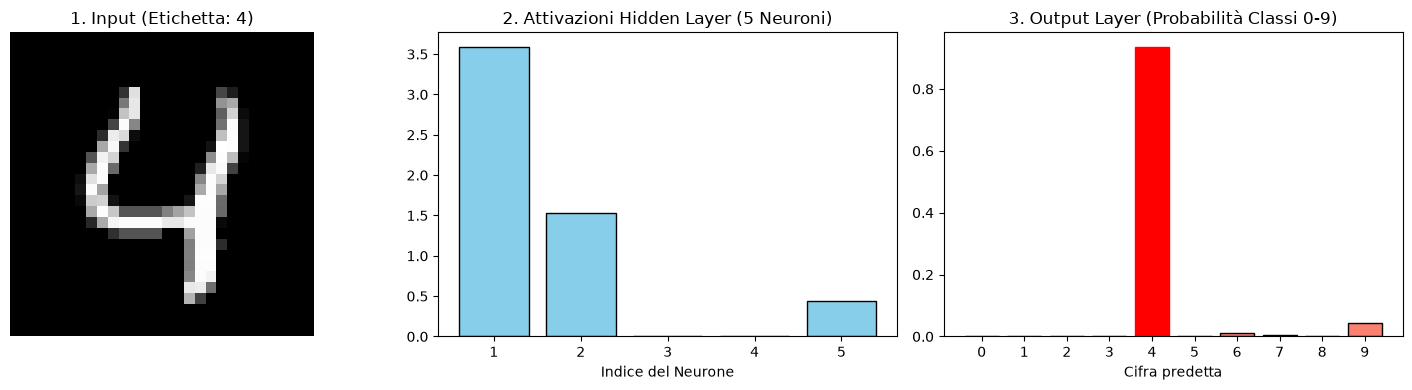

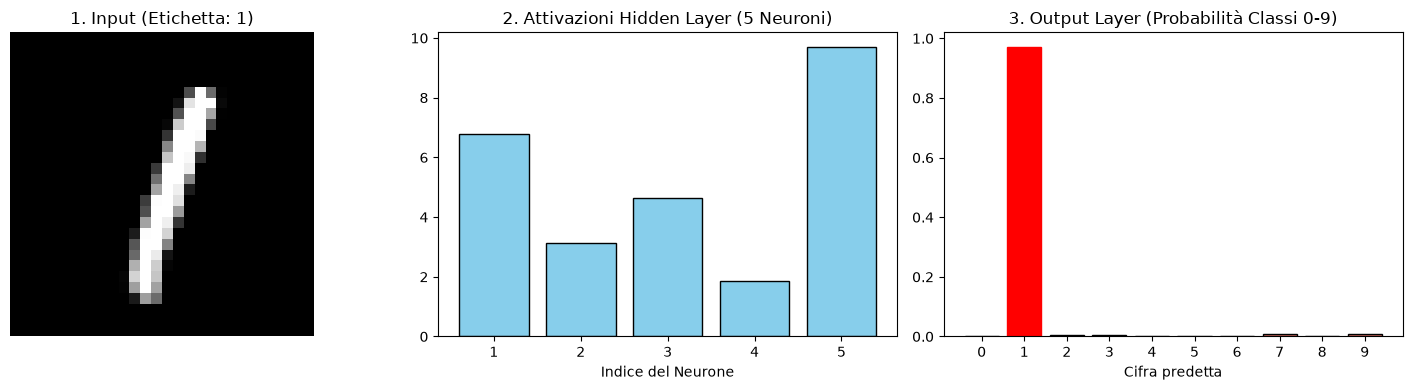

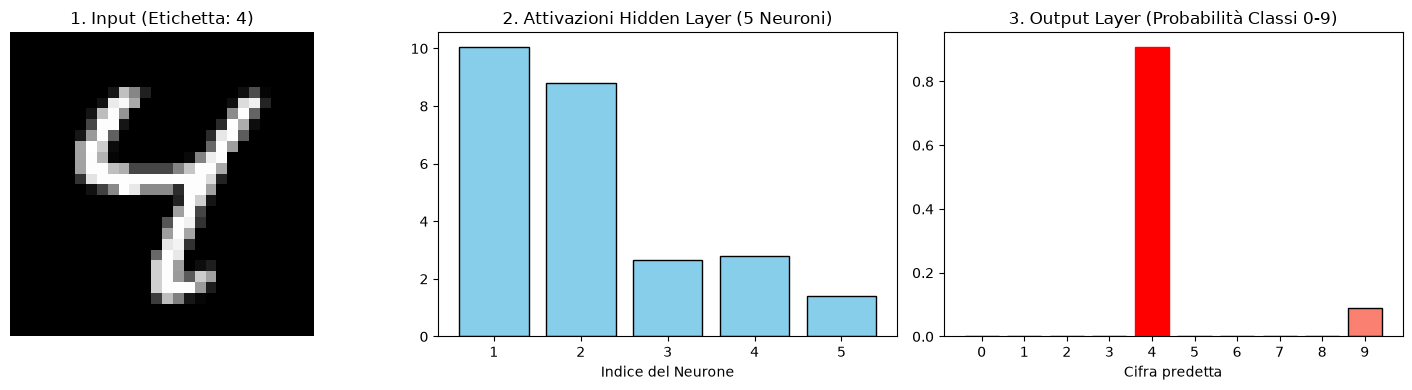

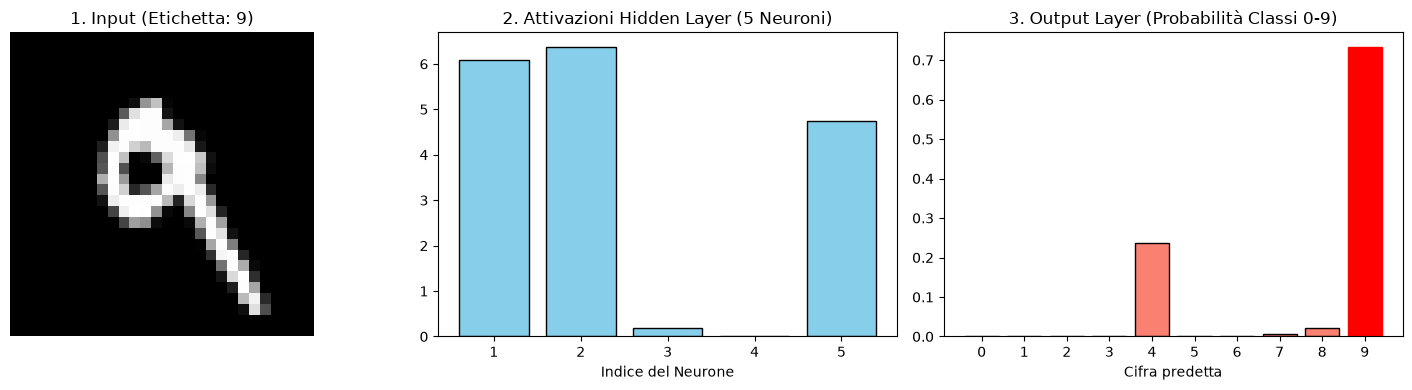

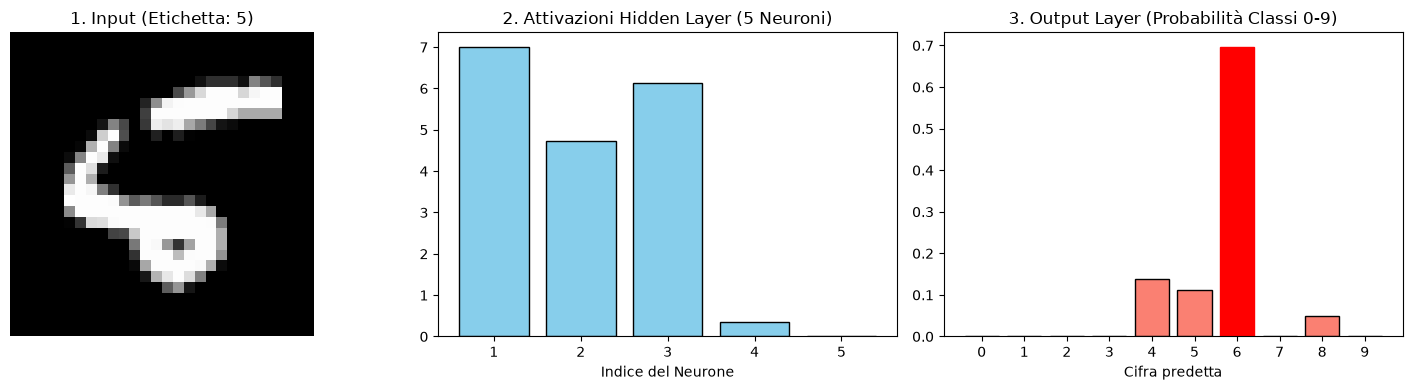

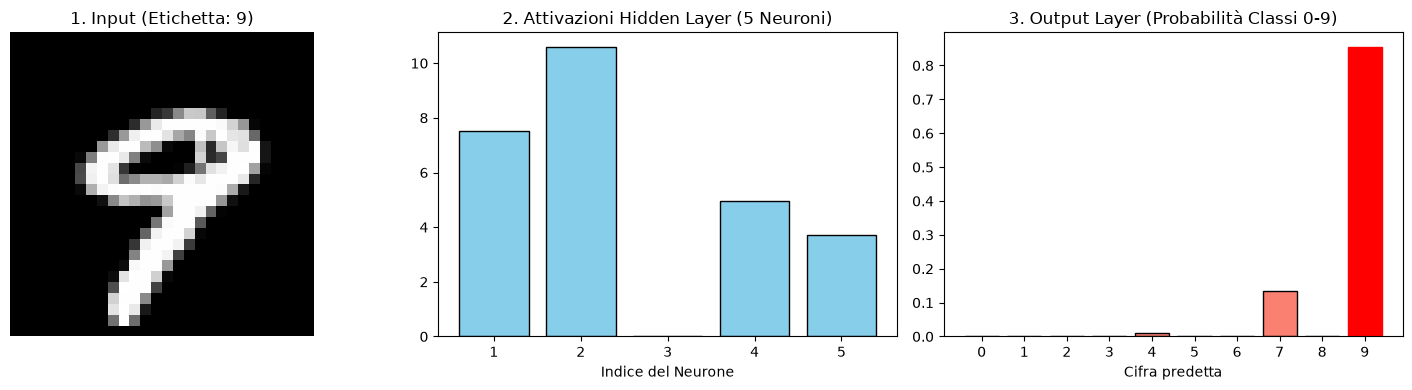

In [7]:
for i in range(0,10):
    indice_scelto = i  # Modifica questo valore per pescare immagini diverse

    # Estraiamo l'immagine e l'etichetta corrispondente
    img_array = test_images[indice_scelto : indice_scelto+1]
    true_label = test_labels[indice_scelto]

    # forward pass per estrarre i valori ai vari stadi ed estrarre le attivazioni del layer nascosto
    hidden_activations = extractor.predict(img_array, verbose=0)[0]
    output_probabilities = model_toy.predict(img_array, verbose=0)[0]

    # visualizzazione a tre stadi: input, layer nascosto, output
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

    #input
    ax1.imshow(img_array[0], cmap='gray')
    ax1.set_title(f"1. Input (Etichetta: {true_label})", fontsize=12)
    ax1.axis('off')

    # layer nascosto (le feature estratte)
    ax2.bar(range(1, 6), hidden_activations, color='skyblue', edgecolor='black')
    ax2.set_title("2. Attivazioni Hidden Layer (5 Neuroni)", fontsize=12)
    ax2.set_xlabel("Indice del Neurone")
    ax2.set_xticks(range(1, 6))

    # output (la decisione)
    ax3.bar(range(10), output_probabilities, color='salmon', edgecolor='black')
    ax3.set_title("3. Output Layer (Probabilità Classi 0-9)", fontsize=12)
    ax3.set_xlabel("Cifra predetta")
    ax3.set_xticks(range(10))

    # Evidenziamo di rosso la predizione più alta nell'output
    predicted_digit = np.argmax(output_probabilities)
    ax3.patches[predicted_digit].set_color('red')

    plt.tight_layout()
    plt.show()



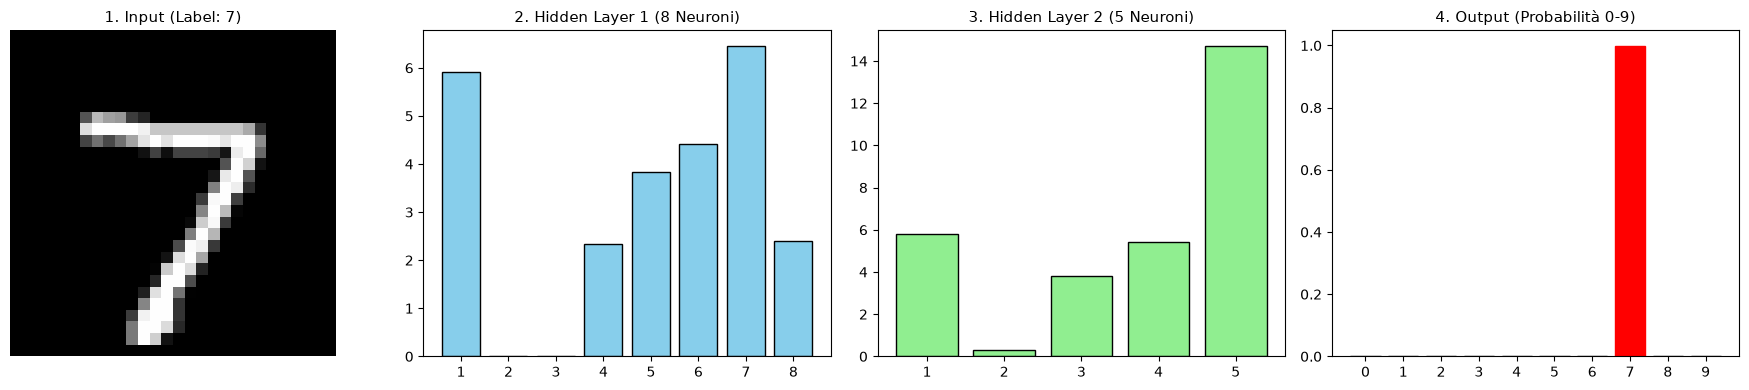

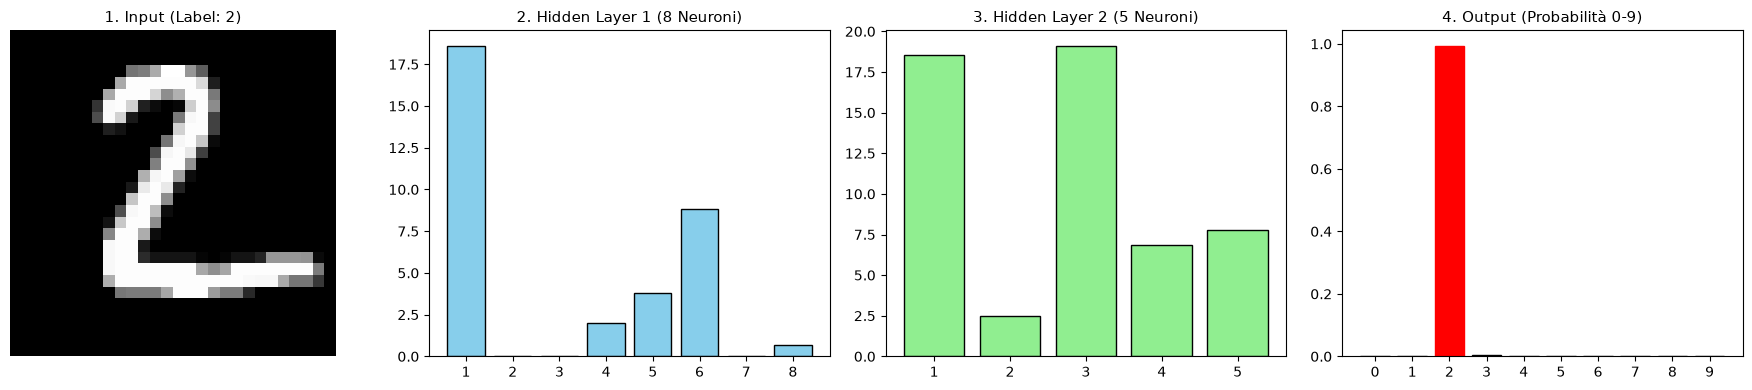

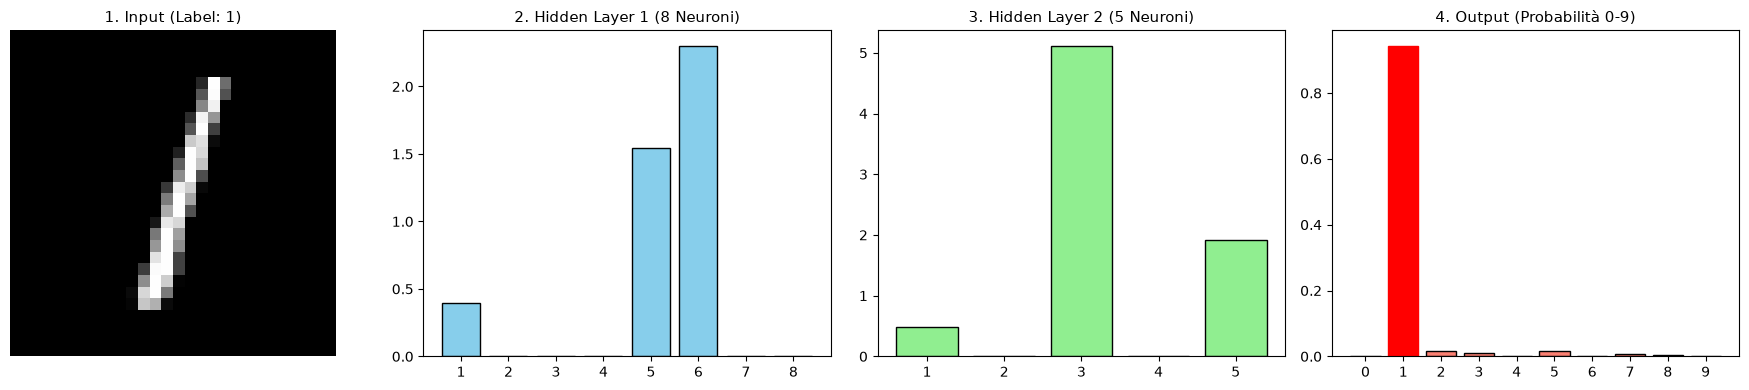

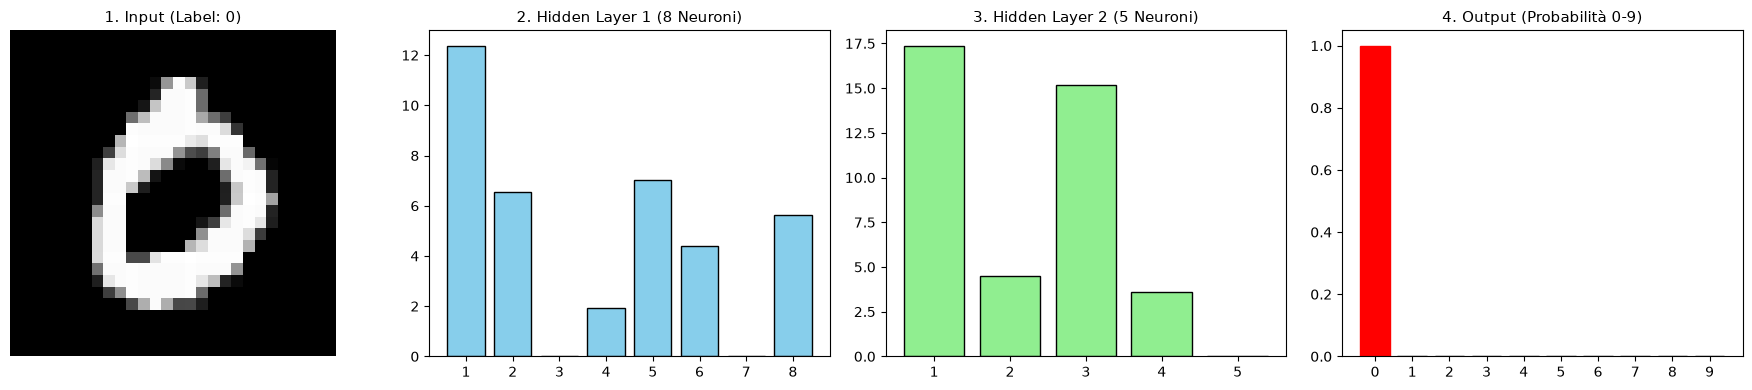

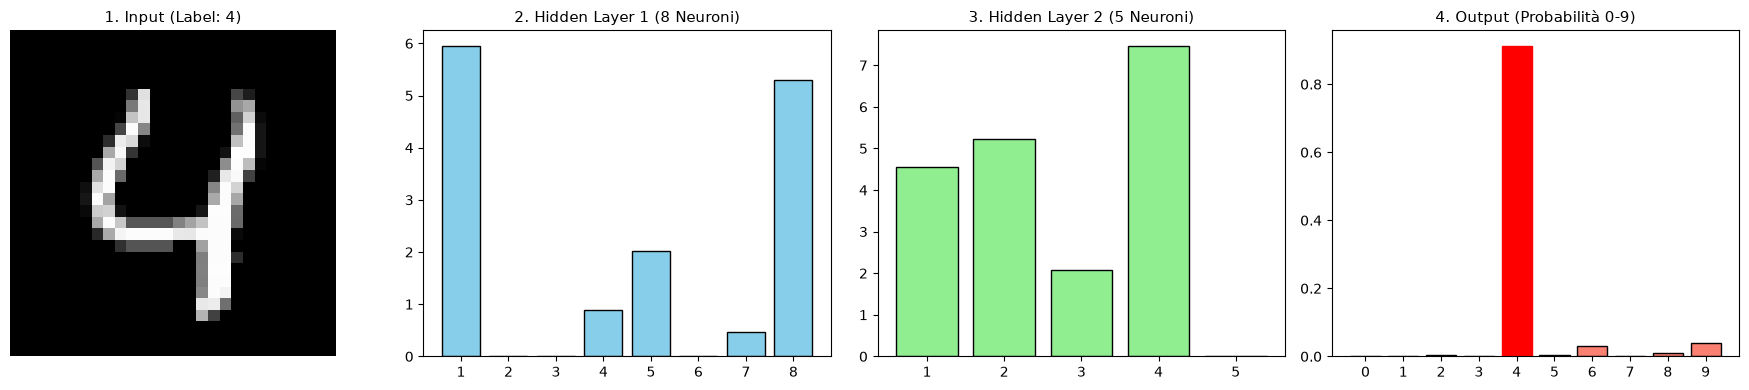

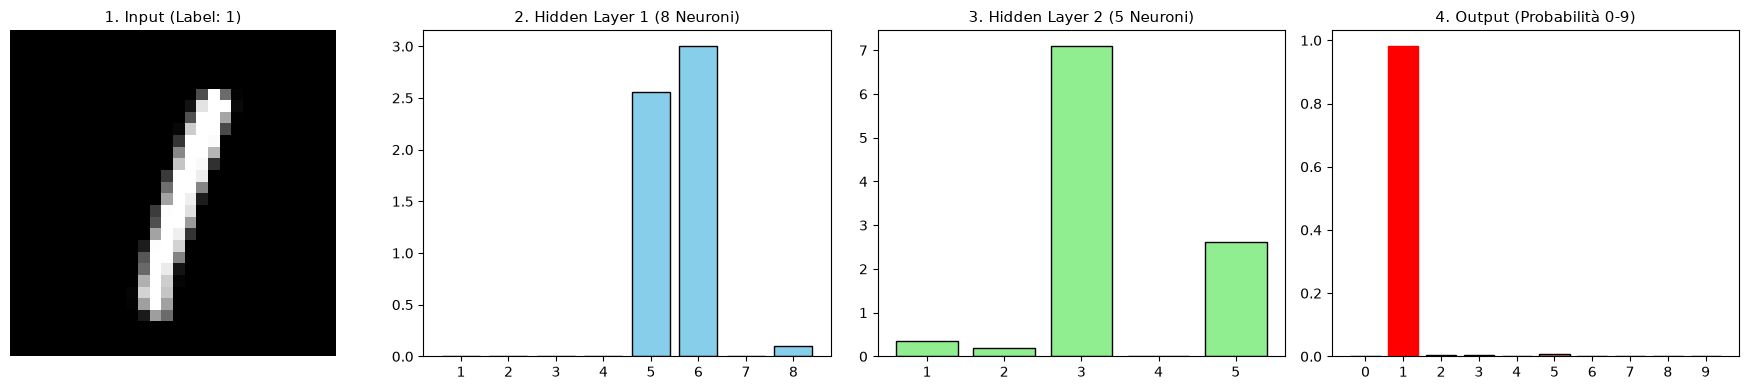

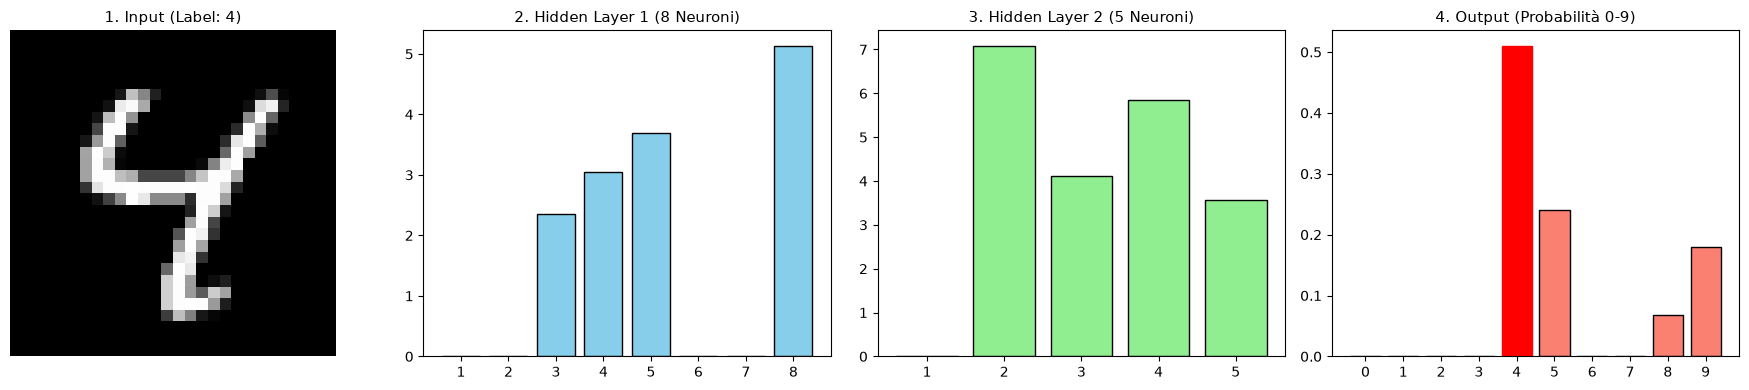

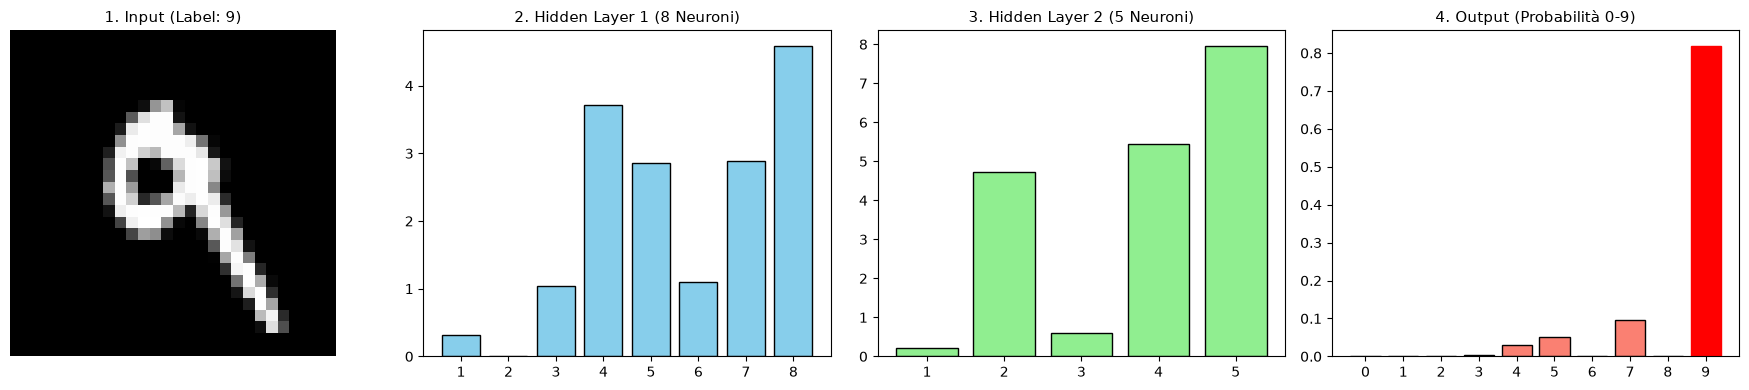

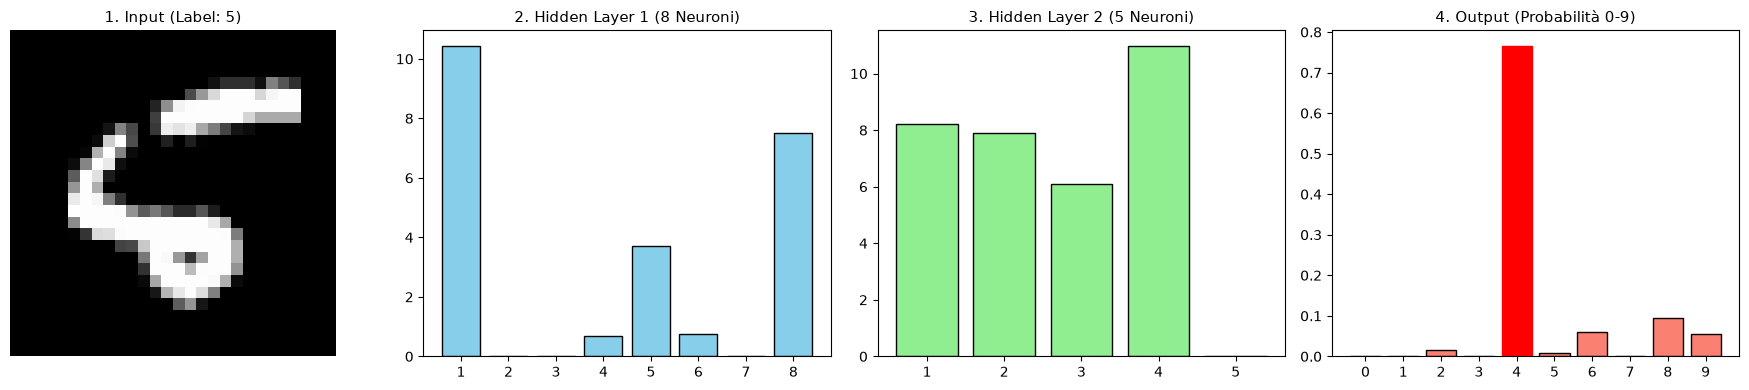

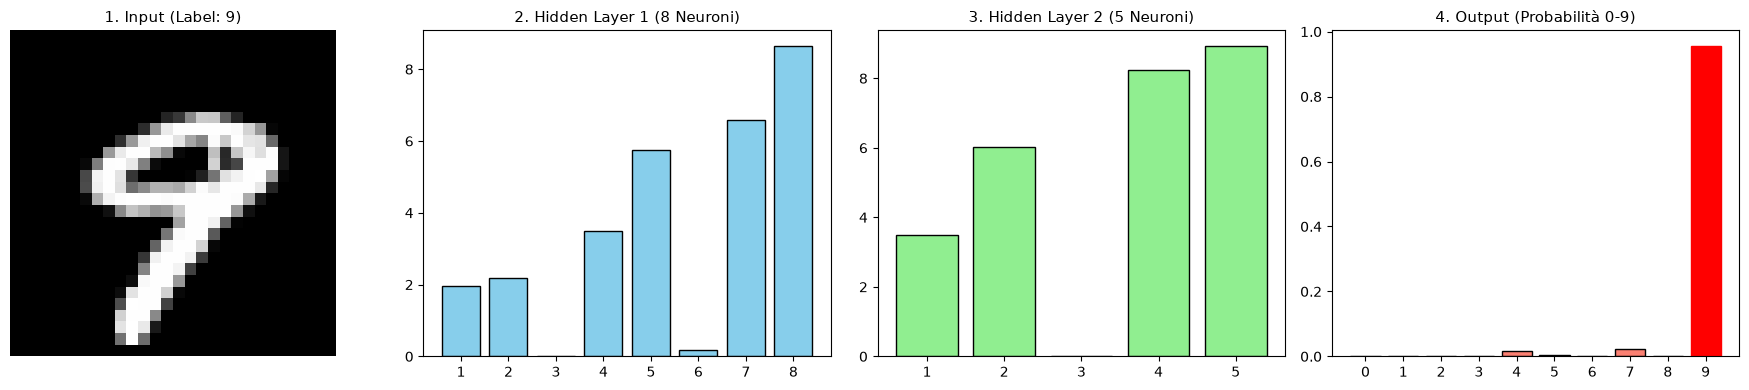

In [8]:
# modello con due hidden layer
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
hidden1_out = Dense(8, activation='relu', name='hidden_1')(x)
hidden2_out = Dense(5, activation='relu', name='hidden_2')(hidden1_out)
outputs = Dense(10, activation='softmax', name='output_layer')(hidden2_out)

model_deep = Model(inputs=inputs, outputs=outputs)
model_deep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Addestramento veloce per fare in modo che i neuroni assumano pesi specifici
model_deep.fit(train_images, train_labels, epochs=3, verbose=0)

# estrattore indipendente per ciascun livello nascosto che serve a catturare le attivazioni dei neuroni
extractor_1 = Model(inputs=inputs, outputs=hidden1_out)
extractor_2 = Model(inputs=inputs, outputs=hidden2_out)

for i in range(0, 10):
    indice_scelto = i 
    img_array = test_images[indice_scelto : indice_scelto+1]
    true_label = test_labels[indice_scelto]

    # Eseguiamo il "Forward Pass" per estrarre i valori ai vari stadi
    act_h1 = extractor_1.predict(img_array, verbose=0)[0]
    act_h2 = extractor_2.predict(img_array, verbose=0)[0]
    out_probs = model_deep.predict(img_array, verbose=0)[0]

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 4))

    # input
    ax1.imshow(img_array[0], cmap='gray')
    ax1.set_title(f"1. Input (Label: {true_label})", fontsize=11)
    ax1.axis('off')

    # primo hidden layer
    ax2.bar(range(1, 9), act_h1, color='skyblue', edgecolor='black')
    ax2.set_title("2. Hidden Layer 1 (8 Neuroni)", fontsize=11)
    ax2.set_xticks(range(1, 9))

    # secondo hidden layer
    ax3.bar(range(1, 6), act_h2, color='lightgreen', edgecolor='black')
    ax3.set_title("3. Hidden Layer 2 (5 Neuroni)", fontsize=11)
    ax3.set_xticks(range(1, 6))

    # output
    ax4.bar(range(10), out_probs, color='salmon', edgecolor='black')
    ax4.set_title("4. Output (Probabilità 0-9)", fontsize=11)
    ax4.set_xticks(range(10))
    
    predicted_digit = np.argmax(out_probs)
    ax4.patches[predicted_digit].set_color('red')
    
    plt.tight_layout()
    plt.show()

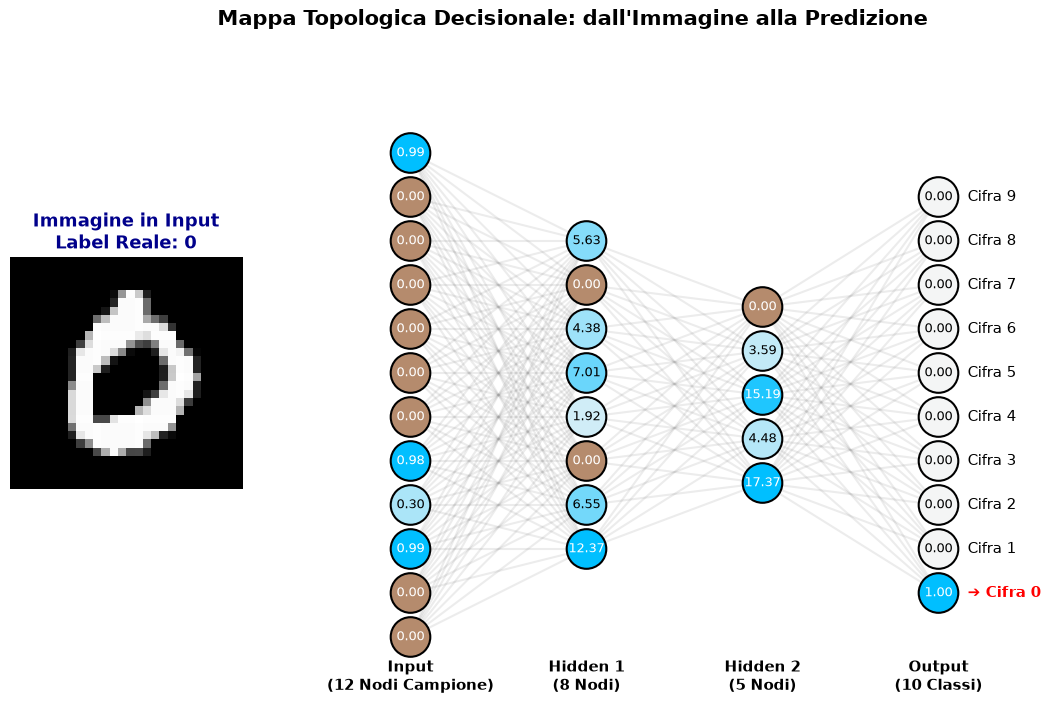

In [9]:
indice_scelto = 3  # Cambia questo indice per provare altre immagini
img_array = test_images[indice_scelto : indice_scelto+1]
true_label = test_labels[indice_scelto]

# Estraiamo nuovamente le attivazioni in caso l'indice sia cambiato
act_h1 = extractor_1.predict(img_array, verbose=0)[0]
act_h2 = extractor_2.predict(img_array, verbose=0)[0]
out_probs = model_deep.predict(img_array, verbose=0)[0]

pixel_appiattiti = img_array[0].flatten()
idx_pixels = np.linspace(200, 550, 12, dtype=int)
input_sample = pixel_appiattiti[idx_pixels]

layers = [input_sample, act_h1, act_h2, out_probs]
layer_names = ["Input\n(12 Nodi Campione)", "Hidden 1\n(8 Nodi)", "Hidden 2\n(5 Nodi)", "Output\n(10 Classi)"]
layer_sizes = [len(l) for l in layers]
max_size = max(layer_sizes)

fig = plt.figure(figsize=(15, 8))

# immagine a sinistra
ax_img = fig.add_subplot(1, 5, 1)
ax_img.imshow(img_array[0], cmap='gray')
ax_img.set_title(f"Immagine in Input\nLabel Reale: {true_label}", fontsize=13, fontweight='bold', color='darkblue')
ax_img.axis('off')

# la rete a destra
ax_net = fig.add_subplot(1, 5, (2, 5))
ax_net.axis('off')
ax_net.set_aspect('equal') 

x_space = 4 
ax_net.set_xlim(-1, (len(layers) - 1) * x_space + 2.5) # Spazio extra per le etichette finali
ax_net.set_ylim(-1, max_size + 1)

cmap_nodes = LinearSegmentedColormap.from_list('marrone_azzurro', ['saddlebrown', 'whitesmoke', 'deepskyblue'])

# Disegno delle Sinapsi
for i in range(len(layers) - 1):
    for a in range(layer_sizes[i]):
        for b in range(layer_sizes[i+1]):
            x_a, x_b = i * x_space, (i + 1) * x_space
            y_a = (max_size - layer_sizes[i]) / 2.0 + a
            y_b = (max_size - layer_sizes[i+1]) / 2.0 + b
            ax_net.plot([x_a, x_b], [y_a, y_b], color='gray', alpha=0.15, zorder=1)

# Disegno dei Nodi e delle Etichette
raggio_neurone = 0.45 
for i, act_layer in enumerate(layers):
    size = len(act_layer)
    y_coords = np.arange(size) + (max_size - size) / 2.0
    x_coords = np.full(size, i * x_space)
    
    act_norm = act_layer / (np.max(act_layer) + 1e-9)
    ax_net.text(i * x_space, -1.2, layer_names[i], ha='center', fontsize=11, fontweight='bold')
    
    for idx_nodo, (x, y, val, norm) in enumerate(zip(x_coords, y_coords, act_layer, act_norm)):
        color_val = 0.5 + (norm * 0.5) 
        if val == 0: color_val = 0.2 
            
        colore_sfondo = cmap_nodes(color_val)
        cerchio = patches.Circle((x, y), radius=raggio_neurone, facecolor=colore_sfondo, 
                                 edgecolor='black', linewidth=1.5, zorder=2)
        ax_net.add_patch(cerchio)
        
        colore_testo = 'black' if 0.3 < color_val < 0.8 else 'white'
        ax_net.text(x, y, f'{val:.2f}', ha='center', va='center', 
                    fontsize=9, color=colore_testo, zorder=3)
        
        # etichette (Cifra 0-9) accanto al livello di Output
        if i == len(layers) - 1:
            is_max = (val == np.max(act_layer))
            fw = 'bold' if is_max else 'normal'
            fc = 'red' if is_max else 'black'
            testo_etichetta = f' ➔ Cifra {idx_nodo}' if is_max else f' Cifra {idx_nodo}'
            ax_net.text(x + raggio_neurone + 0.1, y, testo_etichetta, 
                        ha='left', va='center', fontsize=11, fontweight=fw, color=fc)

plt.suptitle("Mappa Topologica Decisionale: dall'Immagine alla Predizione", fontsize=15, fontweight='bold', y=0.95)
plt.subplots_adjust(wspace=0) # Riduciamo lo spazio tra immagine e rete
plt.show()

### Teoria: visualizzazione dei risultati

Per ogni prova (`trial`) salvata in `trials`, plottiamo l'accuracy ottenuta rispetto a tre grandezze diverse, per capire come i due iperparametri influenzano la performance:

1. **Iterazione** (`tid`): dopo la fase iniziale di campionamento casuale (le prime `n_startup_jobs` prove) l'accuracy tende a migliorare, perche' TPE affina la ricerca sfruttando le prove precedenti. Il confine tra le due fasi e' evidenziato nel grafico da una linea tratteggiata.
2. **layer_size**: mostra se un hidden layer piu' grande aiuta la classificazione. Attenzione: `t['misc']['vals']['layer_size']` restituisce l'**indice** della scelta di `hp.choice` (0-4), non il numero di unita': va rimappato sui valori veri, altrimenti l'asse x e' privo di significato.
3. **learning_rate**: mostra la sensibilita' del modello al learning rate — spesso esiste un valore "ottimale", ne' troppo piccolo (convergenza lenta) ne' troppo grande (instabilita'). Essendo campionato in modo log-uniforme su piu' ordini di grandezza, l'asse x va messo in **scala logaritmica**, altrimenti i punti si accumulano tutti vicino allo zero.

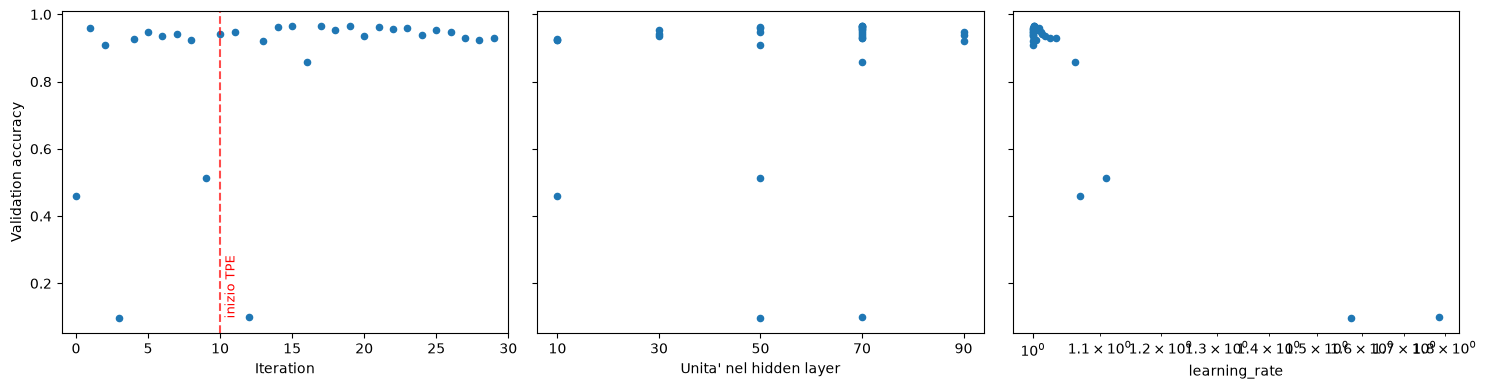

In [10]:
# Punto 3: Plot dell'accuracy rispetto a iterazione, layer_size e learning_rate per ogni trial
_, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15, 4))

ys = [-t['result']['loss'] for t in trials.trials]  # accuracy di validazione di ogni prova

xs = [t['tid'] for t in trials.trials]
ax1.set_xlim(xs[0]-1, xs[-1]+1)
ax1.scatter(xs, ys, s=20)
ax1.axvline(10, color='red', linestyle='--', alpha=0.7)  # fine della fase random (n_startup_jobs)
ax1.text(10.3, min(ys), 'inizio TPE', color='red', fontsize=9, rotation=90, va='bottom')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Validation accuracy')  # etichetta solo sul primo pannello: l'asse y e' condiviso

# hp.choice restituisce l'indice della scelta: lo rimappiamo sul numero di unita' reale
layer_sizes = np.arange(10, 100, 20)
xs = [layer_sizes[t['misc']['vals']['layer_size'][0]] for t in trials.trials]
ax2.scatter(xs, ys, s=20)
ax2.set_xticks(layer_sizes)
ax2.set_xlabel('Unita\' nel hidden layer')  # la rete ha un solo hidden layer: variamo le unita', non i layer

xs = [np.exp(t['misc']['vals']['learning_rate'][0]) for t in trials.trials]  # loguniform: il valore campionato e' il logaritmo
ax3.scatter(xs, ys, s=20)
ax3.set_xscale('log')  # il learning rate copre piu' ordini di grandezza
ax3.set_xlabel('learning_rate')

plt.tight_layout()
plt.show()

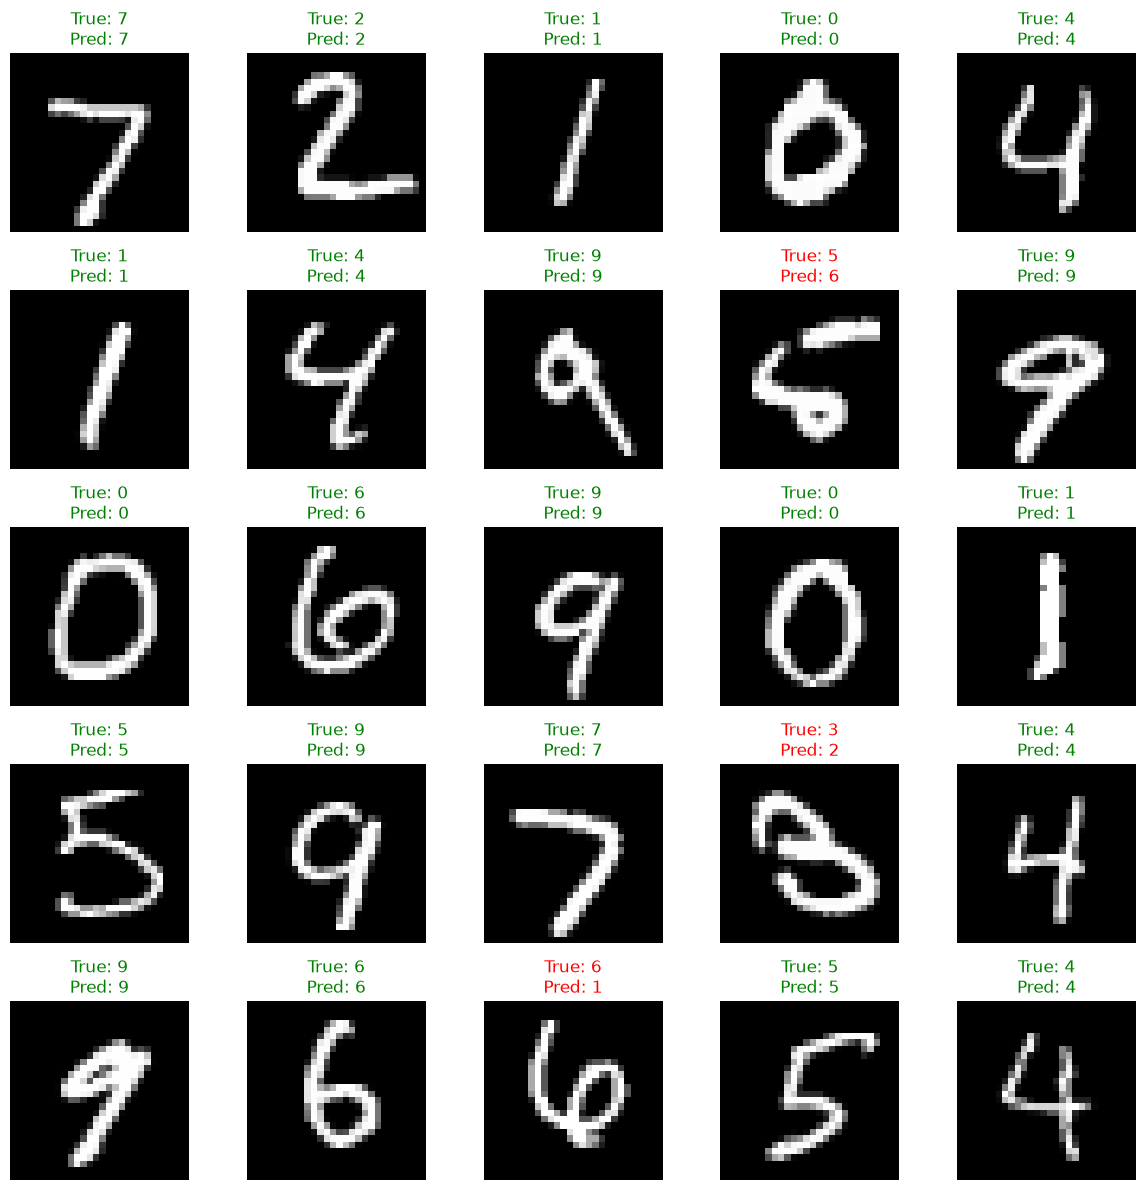

In [11]:
# tabella come quella iniziale con numeri e label, con aggiunta dei risultati della rete con accuracy (verde e rosso per indicare corretto o errato)
def plot_results_table(images, labels, model_toy):
    fig, axes = plt.subplots(5, 5, figsize=(12, 12))
    axes = axes.flatten() # questo serve a trasformare la matrice 5x5 in un array di 25 elementi, cosi' possiamo iterare piu' facilmente
    
    for i in range(25):
        img = images[i]
        true_label = labels[i]
        pred_probs = model_toy.predict(img.reshape(1, 28, 28), verbose=0)[0]
        pred_label = np.argmax(pred_probs)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        
        if pred_label == true_label:
            color = 'green'
        else:
            color = 'red'
        
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    
    plt.tight_layout()
    plt.show()
    
plot_results_table(test_images, test_labels, model_toy)


### cosa imparano i neuroni

**Mechanistic Interpretability: I "Template" della Rete Neurale**

Questa sezione esplora cosa hanno imparato fisicamente i neuroni durante l'addestramento, trasformando le matrici dei pesi in immagini 28x28. Poiché usiamo layer di tipo `Dense`, ogni neurone intermedio è connesso a tutti i pixel di input: mappare i suoi pesi ci permette di visualizzare la sagoma geometrica che sta "cercando" nello spazio.

* **Layer 1 (Feature di base):** Rimodellando i 784 pesi di un singolo neurone in una griglia 28x28, otteniamo la sua mappa termica decisionale.
    * **Aree Rosse (Pesi Positivi):** Zone di eccitazione. Se l'immagine in ingresso presenta inchiostro in questi specifici pixel, il neurone si accende.
    * **Aree Blu (Pesi Negativi):** Zone di inibizione. L'inchiostro in questi pixel indica che la forma non corrisponde al target del neurone, causandone lo spegnimento.
* **Layer 2 (Astrazione complessa):** Per visualizzare il secondo strato nello spazio originale dell'immagine, eseguiamo una proiezione matematica moltiplicando i pesi del primo layer per quelli del secondo. Mentre il primo livello cattura tratti elementari (linee dritte o angoli), il secondo assembla queste feature primarie per comporre sagome più complesse, spesso simili a "fantasmi" di intere cifre sovrapposte.
    * **Attenzione:** questo prodotto matriciale ignora la ReLU che sta *tra* i due layer. È quindi la **linearizzazione** del neurone, non il suo comportamento esatto: i "fantasmi" mostrano cosa cercherebbe il neurone se la rete fosse puramente lineare, e vanno letti come approssimazione qualitativa.

Questo approccio visivo costituisce le fondamenta logiche del **linear probing**: dimostra visivamente come un modello profondo, guidato unicamente dalla necessità di minimizzare l'errore finale, sia in grado di codificare autonomamente proprietà strutturali avanzate partendo dai dati grezzi in input.

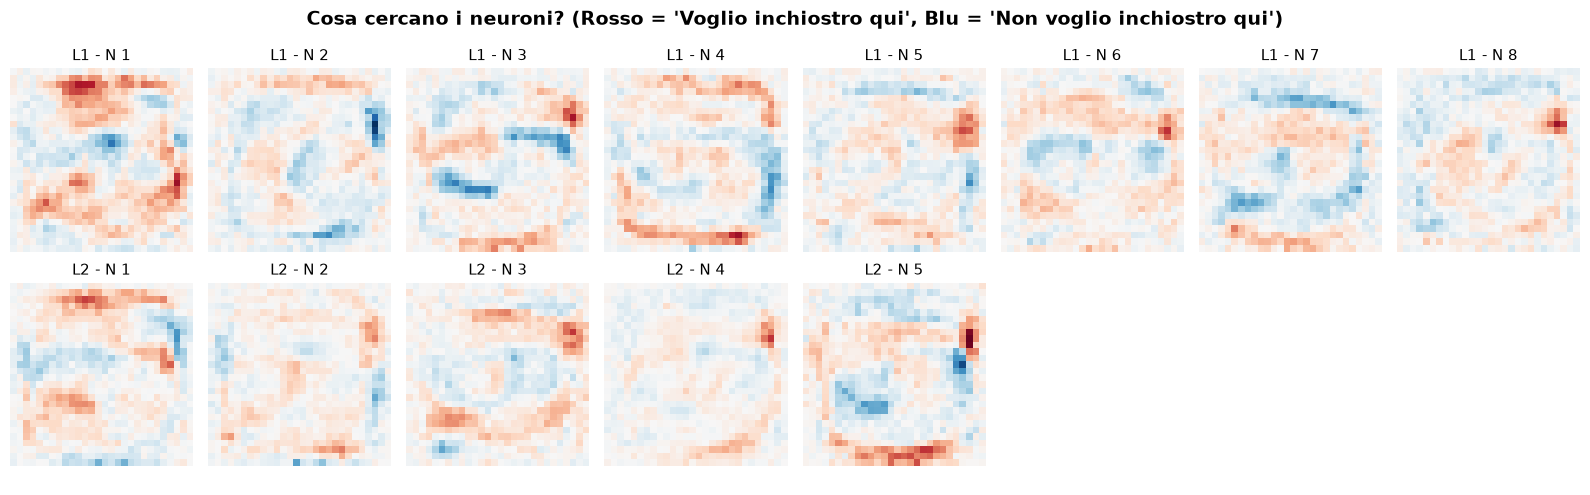

In [12]:
# Estraiamo le matrici dei pesi dai due layer
w1, _ = model_deep.get_layer('hidden_1').get_weights()  # Forma: (784, 8)
w2, _ = model_deep.get_layer('hidden_2').get_weights()  # Forma: (8, 5)

# proiettiamo il Layer 2 nello spazio dei 784 pixel originali
# NB: il prodotto w1 @ w2 trascura la ReLU tra i due layer -> e' un'approssimazione lineare
w2_proiettato = np.dot(w1, w2)  # Forma: (784, 5)

# Prepariamo la tela per i due livelli
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Cosa cercano i neuroni? (Rosso = 'Voglio inchiostro qui', Blu = 'Non voglio inchiostro qui')", 
             fontsize=14, fontweight='bold')

# riga 1: hidden layer 1 (8 neuroni)
vmax_1 = np.max(np.abs(w1))
for i in range(8):
    ax = axes[0, i]
    # Rimodelliamo i 784 pesi del neurone i in un'immagine 28x28
    template = w1[:, i].reshape(28, 28)
    # Usiamo la colormap 'RdBu_r' (Rosso/Bianco/Blu) centrata sullo zero
    im = ax.imshow(template, cmap='RdBu_r', vmin=-vmax_1, vmax=vmax_1)
    ax.set_title(f"L1 - N {i+1}", fontsize=11)
    ax.axis('off')

# riga 2: hidden layer 2 (5 neuroni), proiettati nello spazio dei pixel originali
vmax_2 = np.max(np.abs(w2_proiettato))
for i in range(5):
    ax = axes[1, i]
    template = w2_proiettato[:, i].reshape(28, 28)
    ax.imshow(template, cmap='RdBu_r', vmin=-vmax_2, vmax=vmax_2)
    ax.set_title(f"L2 - N {i+1}", fontsize=11)
    ax.axis('off')
    
# grafici vuoti per completare la griglia 2x8
for i in range(5, 8):
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

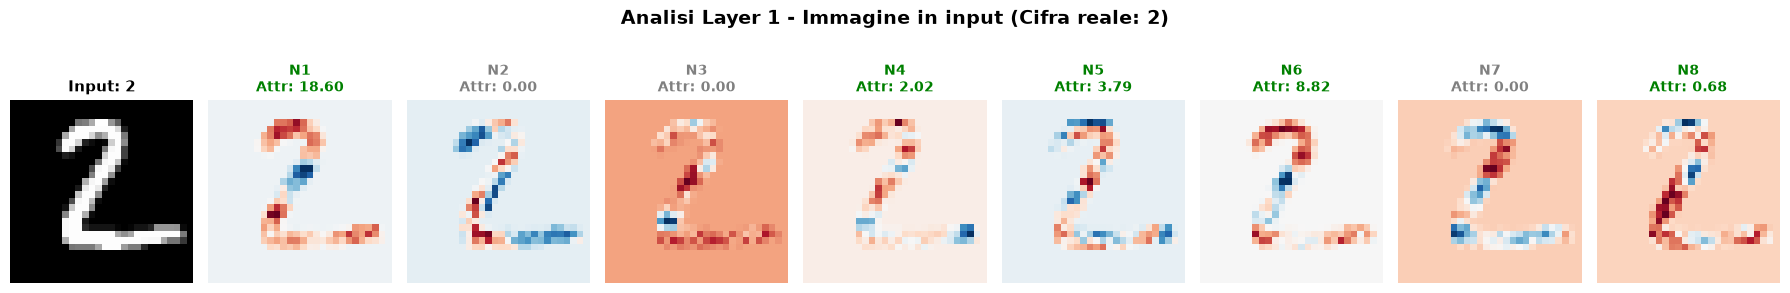

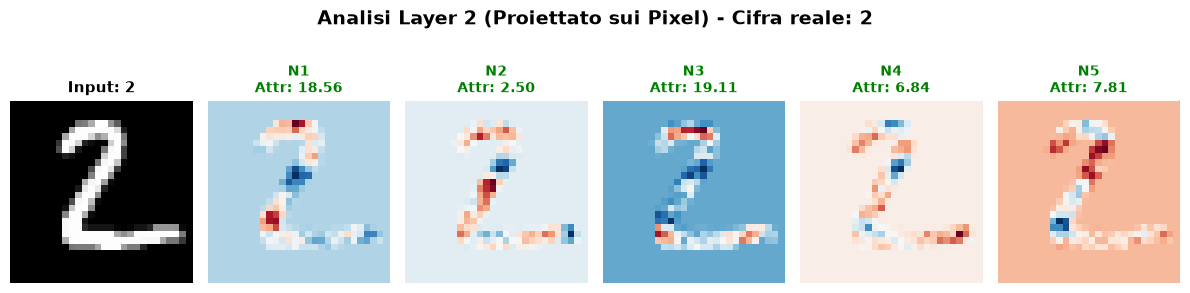

In [13]:
import matplotlib.pyplot as plt
import numpy as np

indice_scelto = 1 
img_da_testare = test_images[indice_scelto]
label_reale = test_labels[indice_scelto]

w1, _ = model_deep.get_layer('hidden_1').get_weights()  # Forma: (784, 8)
w2, _ = model_deep.get_layer('hidden_2').get_weights()  # Forma: (8, 5)
w2_proiettato = np.dot(w1, w2)                          # Forma: (784, 5)

attivazioni_h1 = extractor_1.predict(test_images[indice_scelto : indice_scelto+1], verbose=0)[0]
attivazioni_h2 = extractor_2.predict(test_images[indice_scelto : indice_scelto+1], verbose=0)[0]

# layer 1: visualizzazione delle attivazioni dei neuroni rispetto all'immagine in input
fig, axes = plt.subplots(1, 9, figsize=(18, 3))
fig.suptitle(f"Analisi Layer 1 - Immagine in input (Cifra reale: {label_reale})", fontsize=14, fontweight='bold', y=1.05)

axes[0].imshow(img_da_testare, cmap='gray')
axes[0].set_title(f"Input: {label_reale}", fontsize=11, fontweight='bold')
axes[0].axis('off')

for i in range(8):
    ax = axes[i + 1]
    template = w1[:, i].reshape(28, 28)
    sovrapposizione = img_da_testare * template
    ax.imshow(sovrapposizione, cmap='RdBu_r')
    attivazione_val = attivazioni_h1[i]
    colore_titolo = 'green' if attivazione_val > 0 else 'gray'
    ax.set_title(f"N{i+1}\nAttr: {attivazione_val:.2f}", fontsize=10, color=colore_titolo, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# layer 2: visualizzazione delle attivazioni dei neuroni rispetto all'immagine in input
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
fig.suptitle(f"Analisi Layer 2 (Proiettato sui Pixel) - Cifra reale: {label_reale}", fontsize=14, fontweight='bold', y=1.05)

axes[0].imshow(img_da_testare, cmap='gray')
axes[0].set_title(f"Input: {label_reale}", fontsize=11, fontweight='bold')
axes[0].axis('off')

for i in range(5):
    ax = axes[i + 1]
    template = w2_proiettato[:, i].reshape(28, 28)
    sovrapposizione = img_da_testare * template
    ax.imshow(sovrapposizione, cmap='RdBu_r')
    attivazione_val = attivazioni_h2[i]
    colore_titolo = 'green' if attivazione_val > 0 else 'gray'
    ax.set_title(f"N{i+1}\nAttr: {attivazione_val:.2f}", fontsize=10, color=colore_titolo, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### linear probing

Accuratezza del Linear Probe sul concetto 'Pari/Dispari': 81.30%
  baseline classe maggioritaria:                          50.74%
  sonda lineare sui pixel grezzi (senza rete):            90.12%


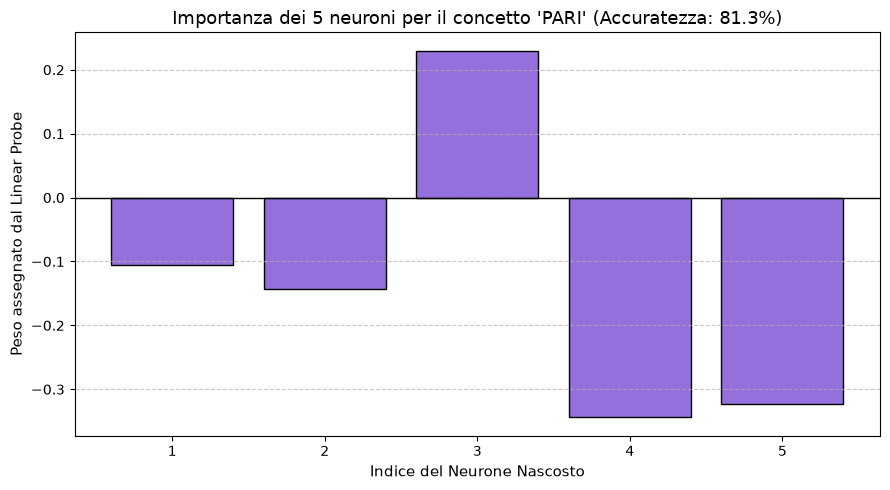

In [14]:
# Creazione delle nuove etichette (Target derivato)
# Se il numero è pari (0, 2, 4, 6, 8), assegniamo 1; altrimenti 0
y_train_even = (train_labels % 2 == 0).astype(int)
y_test_even = (test_labels % 2 == 0).astype(int)

# Estrazione delle feature interne (Inference)
# Usiamo l'estrattore definito in precedenza per congelare la rete
# e tirare fuori i valori dei 5 neuroni per tutto il dataset
X_train_extracted = extractor.predict(train_images, verbose=0)
X_test_extracted = extractor.predict(test_images, verbose=0)

# Linear Probing (Addestramento della Sonda)
# max_iter=1000: con il default (100) il solver non arriva a convergenza su 60000 esempi
linear_probe = LogisticRegression(max_iter=1000)
linear_probe.fit(X_train_extracted, y_train_even)

# Calcoliamo quanto è bravo il probe a indovinare se un numero è pari
probe_accuracy = linear_probe.score(X_test_extracted, y_test_even)

# Due baseline, senza le quali il numero sopra non e' interpretabile:
# 1) classe maggioritaria (quanto farebbe chi risponde sempre "pari")
baseline_maggioritaria = max(y_test_even.mean(), 1 - y_test_even.mean())
# 2) sonda lineare sui pixel grezzi: misura quanto il concetto "pari" sia gia'
#    linearmente separabile PRIMA di passare per la rete
probe_pixels = LogisticRegression(max_iter=1000)
probe_pixels.fit(train_images.reshape(len(train_images), -1), y_train_even)
pixel_accuracy = probe_pixels.score(test_images.reshape(len(test_images), -1), y_test_even)

print(f"Accuratezza del Linear Probe sul concetto 'Pari/Dispari': {probe_accuracy * 100:.2f}%")
print(f"  baseline classe maggioritaria:                          {baseline_maggioritaria * 100:.2f}%")
print(f"  sonda lineare sui pixel grezzi (senza rete):            {pixel_accuracy * 100:.2f}%")

# Creazione del grafico: Quali neuroni hanno imparato questo concetto?
pesi_probe = linear_probe.coef_[0]

plt.figure(figsize=(9, 5))
plt.bar(range(1, 6), pesi_probe, color='mediumpurple', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)

plt.title(f"Importanza dei 5 neuroni per il concetto 'PARI' (Accuratezza: {probe_accuracy * 100:.1f}%)", fontsize=13)
plt.xlabel("Indice del Neurone Nascosto", fontsize=11)
plt.ylabel("Peso assegnato dal Linear Probe", fontsize=11)
plt.xticks(range(1, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

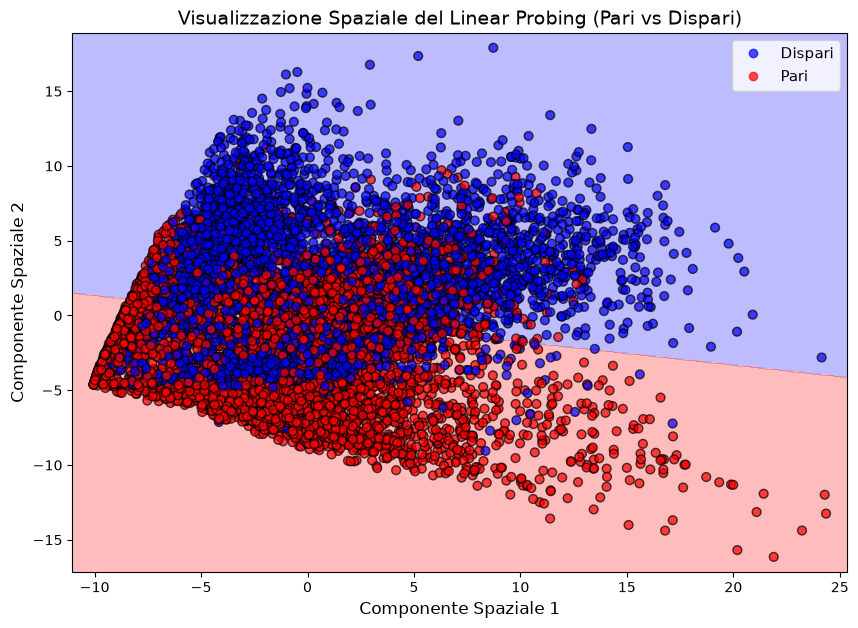

In [15]:
#  Riduciamo le 5 dimensioni interne in 2D per poterle disegnare
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_extracted)

#  Addestriamo una nuova sonda lineare solo su queste 2 dimensioni
# in modo da poter calcolare e disegnare la linea esatta sul grafico.
# NB: PCA e sonda sono fittate sugli stessi dati che poi disegniamo (il test set):
# questo grafico e' una VISUALIZZAZIONE, non una stima di generalizzazione.
probe_2d = LogisticRegression(max_iter=1000)
probe_2d.fit(X_test_2d, y_test_even)

#  Creiamo una "griglia" di punti per disegnare il confine di decisione (la linea)
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Facciamo prevedere alla sonda lineare a quale classe appartiene ogni punto del foglio
Z = probe_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Disegniamo il grafico
plt.figure(figsize=(10, 7))

# Coloriamo lo sfondo per mostrare la linea di taglio netta della regressione
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

# Disegniamo i punti reali: Blu per i Numeri Pari, Rossi per i Dispari
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_even, 
                      cmap='bwr', edgecolor='k', s=40, alpha=0.7)

plt.title("Visualizzazione Spaziale del Linear Probing (Pari vs Dispari)", fontsize=14)
plt.xlabel("Componente Spaziale 1", fontsize=12)
plt.ylabel("Componente Spaziale 2", fontsize=12)

# Aggiungiamo la legenda
handles, _ = scatter.legend_elements()
plt.legend(handles, ["Dispari", "Pari"], loc="best", fontsize=11)

plt.show()

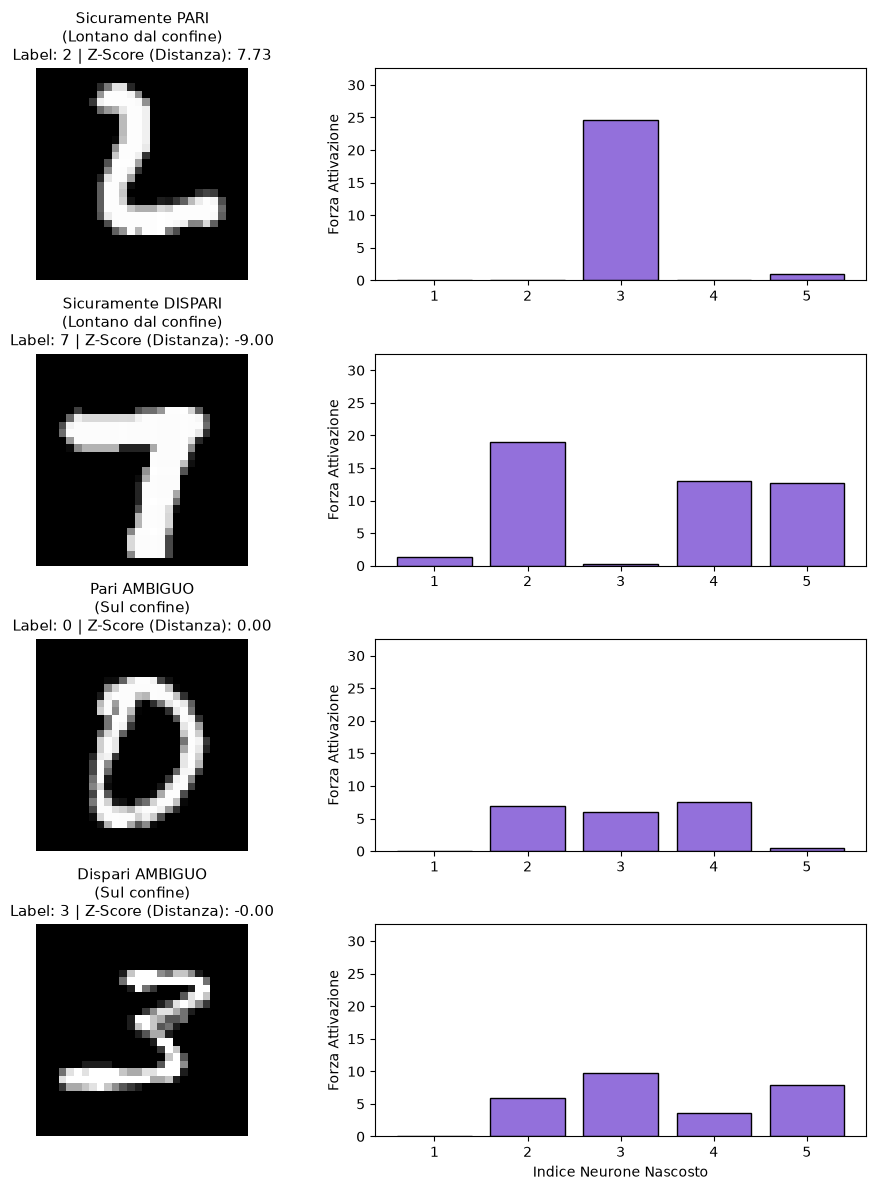

In [16]:
# Calcoliamo la distanza di ogni punto dal confine (Z-Score) usando la sonda 5D
z_scores = linear_probe.decision_function(X_test_extracted)

# Separiamo gli indici delle immagini pari e dispari
even_indices = np.where(y_test_even == 1)[0]
odd_indices = np.where(y_test_even == 0)[0]

# Peschiamo i 4 "Casi Studio"
idx_clear_even = even_indices[np.argmax(z_scores[even_indices])] # Il più positivo in assoluto
idx_clear_odd = odd_indices[np.argmin(z_scores[odd_indices])]    # Il più negativo in assoluto
idx_border_even = even_indices[np.argmin(np.abs(z_scores[even_indices]))] # Vicinissimo a 0
idx_border_odd = odd_indices[np.argmin(np.abs(z_scores[odd_indices]))]    # Vicinissimo a 0

casi_studio = [
    (idx_clear_even, "Sicuramente PARI\n(Lontano dal confine)"),
    (idx_clear_odd, "Sicuramente DISPARI\n(Lontano dal confine)"),
    (idx_border_even, "Pari AMBIGUO\n(Sul confine)"),
    (idx_border_odd, "Dispari AMBIGUO\n(Sul confine)")
]

#  Generiamo il pannello visivo
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
valore_massimo_y = np.max(X_test_extracted) # Per tenere la scala Y identica nei grafici

for i, (idx, titolo) in enumerate(casi_studio):
    img = test_images[idx]
    true_label = test_labels[idx]
    attivazioni = X_test_extracted[idx]
    z_val = z_scores[idx]
    
    # Colonna Sinistra: L'Immagine
    ax_img = axes[i, 0]
    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(f"{titolo}\nLabel: {true_label} | Z-Score (Distanza): {z_val:.2f}", fontsize=11)
    ax_img.axis('off')
    
    # Colonna Destra: Le 5 Attivazioni Interne
    ax_act = axes[i, 1]
    ax_act.bar(range(1, 6), attivazioni, color='mediumpurple', edgecolor='black')
    ax_act.set_xticks(range(1, 6))
    ax_act.set_ylim(0, valore_massimo_y + 0.5)
    ax_act.set_ylabel("Forza Attivazione")
    if i == 3:
        ax_act.set_xlabel("Indice Neurone Nascosto")

plt.tight_layout()
plt.show()